#Avaliação de Modelos de Aprendizado de Máquina para Classificação em Dados Tabulares

Este notebook tem como objetivo apresentar um fluxo completo de aprendizado de máquina supervisionado aplicado a um problema de classificação binária em dados tabulares, seguindo uma abordagem clássica de Machine Learning, conforme proposto no trabalho da disciplina.


## Objetivos

* Compreender o problema de classificação binária em dados tabulares
* Analisar e preparar os dados para modelagem
* Aplicar técnicas adequadas de pré-processamento
* Comparar diferentes modelos de aprendizado de máquina
* Avaliar modelos utilizando métricas como:
  * Matriz de confusão
  * Acurácia
  * Precision
  * Recall
  * F1-score
* Utilizar validação cruzada estratificada
* Identificar o modelo mais promissor e seus hiperparâmetros

## Dataset: Online Shoppers Purchasing Intention

Utilizaremos o dataset Online Shoppers Purchasing Intention (encontrado no UCI Machine Learning Repository), que contém informações sobre sessões de usuários em um site de comércio eletrônico.

O objetivo é prever se uma sessão resultará ou não em uma compra, representada pela variável alvo Revenue.

###Características do dataset

* Problema de classificação binária
* Variável alvo: Revenue (0 = não houve compra, 1 = houve compra)
* Dados tabulares reais
* Mistura de variáveis:
  * Numéricas (contagens, durações, taxas)
  * Categóricas (mês, tipo de visitante, navegador, etc.)

## Por que esse dataset?


* Representa um problema realista de classificação
* Possui desbalanceamento, exigindo métricas adequadas
* Permite comparar diferentes algoritmos de Machine Learning
* Adequado para discutir validação cruzada e escolha de hiperparâmetros

##Importação e montagem do drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV




In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


##Carregando Dataset

In [ ]:
dfShop = pd.read_csv('/content/drive/MyDrive/CDD/online_shoppers_intention.csv', low_memory = False)

In [ ]:
dfShop.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


##

##Análise exploratória


In [ ]:
dfShop.describe(include="all")


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


###Observando amostras por classe

Revenue
False    10422
True      1908
Name: count, dtype: int64


<Axes: title={'center': 'Classes'}, ylabel='count'>

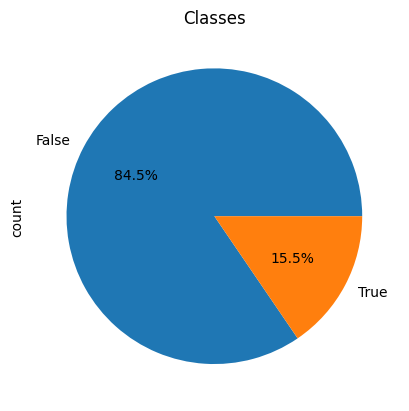

In [ ]:
print(dfShop['Revenue'].value_counts())

dfShop['Revenue'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Classes')

###Tipos das colunas

In [ ]:
dfShop.dtypes


,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


###Valores faltantes

In [ ]:
has_missing = dfShop.isnull().values.any()
print(f"Há valores faltantes? {has_missing}")

Há valores faltantes? False


In [ ]:
missing_data = dfShop.isna().sum()
missing_data_table = pd.DataFrame({'Coluna': missing_data.index, 'Dados Faltantes': missing_data.values})
missing_data_table

,Coluna,Dados Faltantes
0,Administrative,0
1,Administrative_Duration,0
2,Informational,0
3,Informational_Duration,0
4,ProductRelated,0
5,ProductRelated_Duration,0
6,BounceRates,0
7,ExitRates,0
8,PageValues,0
9,SpecialDay,0


###Valores duplicados


In [ ]:
dfShop.duplicated().sum()


np.int64(125)

In [ ]:
dfShop[dfShop.duplicated(keep=False)].sort_values(by=dfShop.columns.tolist()).head(10)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


####Eliminando linhas duplicadas

In [ ]:
dfShop = dfShop.drop_duplicates()


Revenue
False    10297
True      1908
Name: count, dtype: int64


<Axes: title={'center': 'Classes'}, ylabel='count'>

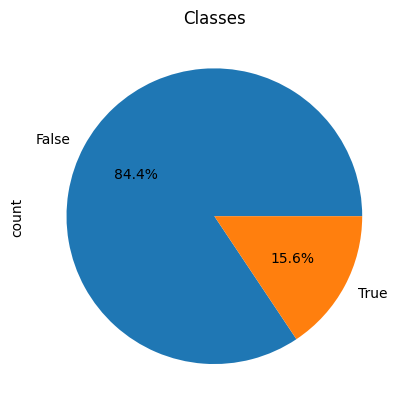

In [ ]:
print(dfShop['Revenue'].value_counts())

dfShop['Revenue'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Classes')

In [ ]:
dfShop.duplicated().sum()


np.int64(0)

###Separando X e Y (Features e Classe)

In [ ]:
X = dfShop.drop(columns='Revenue')
y = dfShop['Revenue']


In [ ]:
print(X.shape)
print(y.shape)

(12205, 17)
(12205,)


###Separando colunas numéricas e categóricas


In [ ]:
num_cols = ['Administrative', 'Administrative_Duration',
            'Informational', 'Informational_Duration',
            'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

cat_cols = ['Month', 'VisitorType', 'Weekend',
            'OperatingSystems', 'Browser', 'Region', 'TrafficType']


In [ ]:
print(f"Numéricas: ", num_cols)
print(f"\n\nCategóricas: ", cat_cols)

Numéricas:  ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


Categóricas:  ['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


## Pré Processamento

Na função preprocessor_scaled, utilizamos o StandardScaler para padronizar as variáveis numéricas e fazemos OneHot Encoding nas categóricas. Já na preprocessor_passthrough, mantém o OneHot Encoding nas categóricas porém não é aplicado nada nas numéricas. As técnocas que envolvem árvores vão passar na passthrough já que não são beneficiadas pela padronização.

In [ ]:
preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

preprocessor_passthrough = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])


## Definição dos moedlos

In [ ]:
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    'KNN': KNeighborsClassifier(),

    'SVM': SVC(
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    'DecisionTree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),

    'GradientBoosting': GradientBoostingClassifier(
        random_state=42
    )
}


###Definição dos pipelines

In [ ]:
pipelines_scaled = {
    'LogisticRegression': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('classifier', models['LogisticRegression'])
    ]),

    'KNN': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('classifier', models['KNN'])
    ]),

    'SVM': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('classifier', models['SVM'])
    ])
}


In [ ]:
pipelines_not_scaled = {
    'DecisionTree': Pipeline([
        ('preprocessor', preprocessor_passthrough),
        ('classifier', models['DecisionTree'])
    ]),

    'RandomForest': Pipeline([
        ('preprocessor', preprocessor_passthrough),
        ('classifier', models['RandomForest'])
    ]),

    'GradientBoosting': Pipeline([
        ('preprocessor', preprocessor_passthrough),
        ('classifier', models['GradientBoosting'])
    ])
}


In [ ]:
pipelines = {}
pipelines.update(pipelines_scaled)
pipelines.update(pipelines_not_scaled)


##KFold estratificado

In [ ]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


##Hiperparâmetros utilizados

In [ ]:
param_grids = {
    'LogisticRegression': {
        'classifier__C': [0.01, 0.1, 1, 10]
    },

    'KNN': {
        'classifier__n_neighbors': [3, 5, 7, 9],
        'classifier__weights': ['uniform', 'distance']
    },

    'SVM': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['rbf']
    },

    'DecisionTree': {
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10]
    },

    'RandomForest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5],
    },

    'GradientBoosting': {
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5]
    }
}


##Separando treino e teste


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# distribuição no treino
print("Treino:")
print(y_train.value_counts(normalize=True))
print()

# distribuição no teste
print("Teste:")
print(y_test.value_counts(normalize=True))


Treino:
Revenue
False    0.843712
True     0.156288
Name: proportion, dtype: float64

Teste:
Revenue
False    0.843507
True     0.156493
Name: proportion, dtype: float64


##GridSearch, testando todas as combinações de hiperparâmetros

In [ ]:
results = []
best_models = {}
best_params = {}


scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}


In [ ]:
for name, pipeline in pipelines.items():
    print(f"\n==============================")
    print(f"Treinando modelo: {name}")
    print(f"==============================")

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring=scoring,
        refit='f1',
        cv=kfold,
        n_jobs=-1
    )

    # 🔹 GridSearch APENAS no conjunto de treino
    grid.fit(X_train, y_train)

    cv_res = grid.cv_results_

    print("\nResultados por combinação de hiperparâmetros (CV):")
    for i in range(len(cv_res['params'])):
        print(f"\nParâmetros: {cv_res['params'][i]}")
        print(f" Accuracy (CV):  {cv_res['mean_test_accuracy'][i]:.3f}")
        print(f" Precision (CV): {cv_res['mean_test_precision'][i]:.3f}")
        print(f" Recall (CV):    {cv_res['mean_test_recall'][i]:.3f}")
        print(f" F1-score (CV):  {cv_res['mean_test_f1'][i]:.3f}")

    # 🔹 Índice do melhor modelo segundo F1
    best_idx = grid.best_index_

    # 🔹 Salvando resultados finais do modelo
    results.append({
        'Model': name,
        'Accuracy (CV)': cv_res['mean_test_accuracy'][best_idx],
        'Precision (CV)': cv_res['mean_test_precision'][best_idx],
        'Recall (CV)': cv_res['mean_test_recall'][best_idx],
        'F1 (CV)': cv_res['mean_test_f1'][best_idx]
    })

    # 🔹 Salvando melhores hiperparâmetros e modelo
    best_params[name] = grid.best_params_
    best_models[name] = grid.best_estimator_


Treinando modelo: LogisticRegression

Resultados por combinação de hiperparâmetros (CV):

Parâmetros: {'classifier__C': 0.01}
 Accuracy (CV):  0.858
 Precision (CV): 0.534
 Recall (CV):    0.746
 F1-score (CV):  0.622

Parâmetros: {'classifier__C': 0.1}
 Accuracy (CV):  0.851
 Precision (CV): 0.516
 Recall (CV):    0.754
 F1-score (CV):  0.613

Parâmetros: {'classifier__C': 1}
 Accuracy (CV):  0.847
 Precision (CV): 0.508
 Recall (CV):    0.755
 F1-score (CV):  0.607

Parâmetros: {'classifier__C': 10}
 Accuracy (CV):  0.846
 Precision (CV): 0.505
 Recall (CV):    0.754
 F1-score (CV):  0.605

Treinando modelo: KNN

Resultados por combinação de hiperparâmetros (CV):

Parâmetros: {'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}
 Accuracy (CV):  0.864
 Precision (CV): 0.594
 Recall (CV):    0.412
 F1-score (CV):  0.486

Parâmetros: {'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
 Accuracy (CV):  0.863
 Precision (CV): 0.588
 Recall (CV):    0.412
 F1-sco

In [ ]:
print("\n==============================")
print("Melhores hiperparâmetros por modelo")
print("==============================")

for model, params in best_params.items():
    print(f"\nModelo: {model}")
    for p, v in params.items():
        print(f"  {p}: {v}")



Melhores hiperparâmetros por modelo

Modelo: LogisticRegression
  classifier__C: 0.01

Modelo: KNN
  classifier__n_neighbors: 7
  classifier__weights: distance

Modelo: SVM
  classifier__C: 1
  classifier__kernel: rbf

Modelo: DecisionTree
  classifier__max_depth: 5
  classifier__min_samples_split: 2

Modelo: RandomForest
  classifier__max_depth: 20
  classifier__min_samples_split: 5
  classifier__n_estimators: 200

Modelo: GradientBoosting
  classifier__learning_rate: 0.1
  classifier__max_depth: 3
  classifier__n_estimators: 100


In [ ]:
results_df = pd.DataFrame(results).sort_values(
    by='F1 (CV)',
    ascending=False
)

results_df


,Model,Accuracy (CV),Precision (CV),Recall (CV),F1 (CV)
4,RandomForest,0.901373,0.694591,0.659893,0.676339
5,GradientBoosting,0.901066,0.726322,0.590423,0.650971
2,SVM,0.869522,0.561030,0.759516,0.645256
0,LogisticRegression,0.858359,0.534049,0.745749,0.622261
3,DecisionTree,0.839307,0.492196,0.828979,0.617408
1,KNN,0.875666,0.679255,0.388576,0.493985


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

final_results = []

for name, model in best_models.items():
    print(f"\n==============================")
    print(f"Avaliação FINAL no TESTE — {name}")
    print(f"==============================")

    # 🔹 Treina com TODO o conjunto de treino
    model.fit(X_train, y_train)

    # 🔹 Predições no teste
    y_pred = model.predict(X_test)

    # 🔹 Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-score:  {f1:.3f}")

    # 🔹 (Opcional) Relatório completo
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 🔹 (Opcional) Matriz de confusão
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    final_results.append({
        'Model': name,
        'Accuracy (Test)': acc,
        'Precision (Test)': prec,
        'Recall (Test)': rec,
        'F1 (Test)': f1
    })



Avaliação FINAL no TESTE — LogisticRegression
Accuracy:  0.861
Precision: 0.538
Recall:    0.801
F1-score:  0.644

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


              precision    recall  f1-score   support

       False       0.96      0.87      0.91      2059
        True       0.54      0.80      0.64       382

    accuracy                           0.86      2441
   macro avg       0.75      0.84      0.78      2441
weighted avg       0.89      0.86      0.87      2441

Confusion Matrix:
[[1796  263]
 [  76  306]]

Avaliação FINAL no TESTE — KNN
Accuracy:  0.875
Precision: 0.682
Recall:    0.382
F1-score:  0.490

Classification Report:
              precision    recall  f1-score   support

       False       0.89      0.97      0.93      2059
        True       0.68      0.38      0.49       382

    accuracy                           0.88      2441
   macro avg       0.79      0.67      0.71      2441
weighted avg       0.86      0.88      0.86      2441

Confusion Matrix:
[[1991   68]
 [ 236  146]]

Avaliação FINAL no TESTE — SVM


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Accuracy:  0.871
Precision: 0.565
Recall:    0.772
F1-score:  0.653

Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      2059
        True       0.57      0.77      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441

Confusion Matrix:
[[1832  227]
 [  87  295]]

Avaliação FINAL no TESTE — DecisionTree
Accuracy:  0.833
Precision: 0.482
Recall:    0.869
F1-score:  0.620

Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.83      0.89      2059
        True       0.48      0.87      0.62       382

    accuracy                           0.83      2441
   macro avg       0.73      0.85      0.76      2441
weighted avg       0.89      0.83      0.85      2441

Confusion Matrix:
[[1702  357]
 [  50  332]]

Avaliação FINAL no TESTE — Ran

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Accuracy:  0.900
Precision: 0.684
Recall:    0.668
F1-score:  0.675

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.68      0.67      0.68       382

    accuracy                           0.90      2441
   macro avg       0.81      0.81      0.81      2441
weighted avg       0.90      0.90      0.90      2441

Confusion Matrix:
[[1941  118]
 [ 127  255]]

Avaliação FINAL no TESTE — GradientBoosting
Accuracy:  0.903
Precision: 0.715
Recall:    0.636
F1-score:  0.673

Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.64      0.67       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441

Confusion Matrix:
[[1962   97]
 [ 139  243]]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
